In [2]:
#install packages
!pip install pandas numpy scikit-learn matplotlib seaborn ucimlrepo xgboost lightgbm catboost

In [3]:
#Import libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [4]:
#unzip file
import zipfile
import os

zip_path = "/content/adult.zip"
extract_path = "/content/adult_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Isi folder setelah extract:")
print(os.listdir(extract_path))

Isi folder setelah extract:
['Index', 'adult.names', 'adult.test', 'adult.data', 'old.adult.names']


In [5]:
#Load Adult dataset
adult = fetch_ucirepo(id=2)

X = adult.data.features.copy()
y = adult.data.targets.copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (48842, 14)
Target shape: (48842, 1)


In [6]:
#Convert target into Series
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

print(y.head())
print(y.unique())

0    <=50K
1    <=50K
2    <=50K
3    <=50K
4    <=50K
Name: income, dtype: object
['<=50K' '>50K' '<=50K.' '>50K.']


In [8]:
#Combine into one dataframe
df = X.copy()
df["target"] = y

print(df.shape)
df.head()

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [10]:
#Clean data
df = df.replace('?', np.nan)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

df["target"] = df["target"].map({
    "<=50K": 0,
    ">50K": 1,
    "<=50K.": 0,
    ">50K.": 1
})

df = df.dropna(subset=["target"]).copy()
df["target"] = df["target"].astype(int)

print(df.shape)
print(df["target"].value_counts())

(48842, 15)
target
0    37155
1    11687
Name: count, dtype: int64


In [11]:
#Check columns
X = df.drop(columns=["target"])
y = df["target"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numerical columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [12]:
#Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [13]:
#Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        verbose=0,
        random_state=42
    )
}

In [14]:
#Evaluation function
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test, scenario_name):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = {
        "Scenario": scenario_name,
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0)
    }

    return metrics, y_pred, pipeline

C. Scenario 1 — In-distribution

In [15]:
#Random split
X_in = df.drop(columns=["target"])
y_in = df["target"]

X_train_in, X_test_in, y_train_in, y_test_in = train_test_split(
    X_in, y_in, test_size=0.2, random_state=42, stratify=y_in
)

print("Train shape:", X_train_in.shape)
print("Test shape:", X_test_in.shape)

Train shape: (39073, 14)
Test shape: (9769, 14)


In [16]:
#Evaluate all models on In-distribution
results = []
saved_predictions = {}

for model_name, model in models.items():
    metrics, y_pred, trained_pipeline = evaluate_model(
        model_name, model,
        X_train_in, X_test_in,
        y_train_in, y_test_in,
        "In-Distribution"
    )
    results.append(metrics)
    saved_predictions[f"In-Distribution_{model_name}"] = (y_test_in, y_pred)

results_df = pd.DataFrame(results)
results_df

[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 792
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 94
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685


,Scenario,Model,Accuracy,Precision,Recall,F1-score
0,In-Distribution,Logistic Regression,0.850650,0.731438,0.594098,0.655653
1,In-Distribution,XGBoost,0.877777,0.788016,0.669376,0.723867
2,In-Distribution,LightGBM,0.877470,0.791220,0.662960,0.721434
3,In-Distribution,CatBoost,0.877572,0.800526,0.650556,0.717791


D. Scenario 2 — Age shift

In [17]:
#Split by age
train_age_df = df[df["age"] < 40].copy()
test_age_df = df[df["age"] >= 40].copy()

print("Train Age Shift:", train_age_df.shape)
print("Test Age Shift:", test_age_df.shape)

print("\nTrain target distribution:")
print(train_age_df["target"].value_counts(normalize=True))

print("\nTest target distribution:")
print(test_age_df["target"].value_counts(normalize=True))

Train Age Shift: (27444, 15)
Test Age Shift: (21398, 15)

Train target distribution:
target
0    0.846706
1    0.153294
Name: proportion, dtype: float64

Test target distribution:
target
0    0.650435
1    0.349565
Name: proportion, dtype: float64


In [18]:
#Evaluate all models on Age Shift
X_train_age = train_age_df.drop(columns=["target"])
y_train_age = train_age_df["target"]

X_test_age = test_age_df.drop(columns=["target"])
y_test_age = test_age_df["target"]

for model_name, model in models.items():
    metrics, y_pred, trained_pipeline = evaluate_model(
        model_name, model,
        X_train_age, X_test_age,
        y_train_age, y_test_age,
        "Age Shift"
    )
    results.append(metrics)
    saved_predictions[f"Age Shift_{model_name}"] = (y_test_age, y_pred)

results_df = pd.DataFrame(results)
results_df

[LightGBM] [Info] Number of positive: 4207, number of negative: 23237
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017013 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 27444, number of used features: 91
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.153294 -> initscore=-1.708996
[LightGBM] [Info] Start training from score -1.708996


,Scenario,Model,Accuracy,Precision,Recall,F1-score
0,In-Distribution,Logistic Regression,0.850650,0.731438,0.594098,0.655653
1,In-Distribution,XGBoost,0.877777,0.788016,0.669376,0.723867
2,In-Distribution,LightGBM,0.877470,0.791220,0.662960,0.721434
3,In-Distribution,CatBoost,0.877572,0.800526,0.650556,0.717791
4,Age Shift,Logistic Regression,0.687214,0.531922,0.876604,0.662089
5,Age Shift,XGBoost,0.814889,0.782651,0.651337,0.710981
6,Age Shift,LightGBM,0.813627,0.774097,0.659225,0.712058
7,Age Shift,CatBoost,0.820123,0.797965,0.650000,0.716422


E. Scenario 3 — Education shift

In [19]:
#Check education categories
sorted(df["education"].dropna().unique())

['10th',
 '11th',
 '12th',
 '1st-4th',
 '5th-6th',
 '7th-8th',
 '9th',
 'Assoc-acdm',
 'Assoc-voc',
 'Bachelors',
 'Doctorate',
 'HS-grad',
 'Masters',
 'Preschool',
 'Prof-school',
 'Some-college']

In [21]:
#Define education groups
train_education_groups = [
    "HS-grad", "Some-college", "11th", "10th", "9th", "12th",
    "Assoc-voc", "Assoc-acdm", "7th-8th", "Preschool", "1st-4th", "5th-6th"
]

test_education_groups = [
    "Bachelors", "Masters", "Doctorate", "Prof-school"
]

train_edu_df = df[df["education"].isin(train_education_groups)].copy()
test_edu_df = df[df["education"].isin(test_education_groups)].copy()

print("Train Education Shift:", train_edu_df.shape)
print("Test Education Shift:", test_edu_df.shape)

print("\nTrain education distribution:")
print(train_edu_df["education"].value_counts())

print("\nTest education distribution:")
print(test_edu_df["education"].value_counts())

Train Education Shift: (36732, 15)
Test Education Shift: (12110, 15)

Train education distribution:
education
HS-grad         15784
Some-college    10878
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
9th               756
12th              657
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

Test education distribution:
education
Bachelors      8025
Masters        2657
Prof-school     834
Doctorate       594
Name: count, dtype: int64


In [22]:
#Evaluate all models on Education Shift
X_train_edu = train_edu_df.drop(columns=["target"])
y_train_edu = train_edu_df["target"]

X_test_edu = test_edu_df.drop(columns=["target"])
y_test_edu = test_edu_df["target"]

for model_name, model in models.items():
    metrics, y_pred, trained_pipeline = evaluate_model(
        model_name, model,
        X_train_edu, X_test_edu,
        y_train_edu, y_test_edu,
        "Education Shift"
    )
    results.append(metrics)
    saved_predictions[f"Education Shift_{model_name}"] = (y_test_edu, y_pred)

results_df = pd.DataFrame(results)
results_df

[LightGBM] [Info] Number of positive: 5867, number of negative: 30865
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 773
[LightGBM] [Info] Number of data points in the train set: 36732, number of used features: 89
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.159724 -> initscore=-1.660279
[LightGBM] [Info] Start training from score -1.660279


,Scenario,Model,Accuracy,Precision,Recall,F1-score
0,In-Distribution,Logistic Regression,0.850650,0.731438,0.594098,0.655653
1,In-Distribution,XGBoost,0.877777,0.788016,0.669376,0.723867
2,In-Distribution,LightGBM,0.877470,0.791220,0.662960,0.721434
3,In-Distribution,CatBoost,0.877572,0.800526,0.650556,0.717791
4,Age Shift,Logistic Regression,0.687214,0.531922,0.876604,0.662089
5,Age Shift,XGBoost,0.814889,0.782651,0.651337,0.710981
6,Age Shift,LightGBM,0.813627,0.774097,0.659225,0.712058
7,Age Shift,CatBoost,0.820123,0.797965,0.650000,0.716422
8,Education Shift,Logistic Regression,0.797440,0.758721,0.848282,0.801006
9,Education Shift,XGBoost,0.797110,0.872425,0.676804,0.762264


F. Result tables

In [23]:
#Clean result table
results_df = results_df[["Scenario", "Model", "Accuracy", "Precision", "Recall", "F1-score"]]
results_df = results_df.sort_values(by=["Scenario", "F1-score"], ascending=[True, False]).reset_index(drop=True)
results_df

,Scenario,Model,Accuracy,Precision,Recall,F1-score
0,Age Shift,CatBoost,0.820123,0.797965,0.650000,0.716422
1,Age Shift,LightGBM,0.813627,0.774097,0.659225,0.712058
2,Age Shift,XGBoost,0.814889,0.782651,0.651337,0.710981
3,Age Shift,Logistic Regression,0.687214,0.531922,0.876604,0.662089
4,Education Shift,Logistic Regression,0.797440,0.758721,0.848282,0.801006
5,Education Shift,XGBoost,0.797110,0.872425,0.676804,0.762264
6,Education Shift,LightGBM,0.791990,0.862349,0.674914,0.757205
7,Education Shift,CatBoost,0.791082,0.880787,0.653780,0.750493
8,In-Distribution,XGBoost,0.877777,0.788016,0.669376,0.723867
9,In-Distribution,LightGBM,0.877470,0.791220,0.662960,0.721434


In [24]:
#Pivot F1 table
pivot_f1 = results_df.pivot(index="Model", columns="Scenario", values="F1-score")
pivot_f1

Scenario,Age Shift,Education Shift,In-Distribution
Model,,,
CatBoost,0.716422,0.750493,0.717791
LightGBM,0.712058,0.757205,0.721434
Logistic Regression,0.662089,0.801006,0.655653
XGBoost,0.710981,0.762264,0.723867


In [25]:
#Calculate performance drop
pivot_f1["Age Shift Drop"] = pivot_f1["In-Distribution"] - pivot_f1["Age Shift"]
pivot_f1["Education Shift Drop"] = pivot_f1["In-Distribution"] - pivot_f1["Education Shift"]
pivot_f1["Average Drop"] = pivot_f1[["Age Shift Drop", "Education Shift Drop"]].mean(axis=1)

pivot_f1 = pivot_f1.sort_values(by="Average Drop")
pivot_f1

Scenario,Age Shift,Education Shift,In-Distribution,Age Shift Drop,Education Shift Drop,Average Drop
Model,,,,,,
Logistic Regression,0.662089,0.801006,0.655653,-0.006437,-0.145353,-0.075895
CatBoost,0.716422,0.750493,0.717791,0.001369,-0.032702,-0.015666
LightGBM,0.712058,0.757205,0.721434,0.009376,-0.035771,-0.013198
XGBoost,0.710981,0.762264,0.723867,0.012885,-0.038397,-0.012756


In [26]:
#Add stability rank
pivot_f1["Stability Rank"] = range(1, len(pivot_f1) + 1)
pivot_f1

Scenario,Age Shift,Education Shift,In-Distribution,Age Shift Drop,Education Shift Drop,Average Drop,Stability Rank
Model,,,,,,,
Logistic Regression,0.662089,0.801006,0.655653,-0.006437,-0.145353,-0.075895,1
CatBoost,0.716422,0.750493,0.717791,0.001369,-0.032702,-0.015666,2
LightGBM,0.712058,0.757205,0.721434,0.009376,-0.035771,-0.013198,3
XGBoost,0.710981,0.762264,0.723867,0.012885,-0.038397,-0.012756,4


G. Visualizations

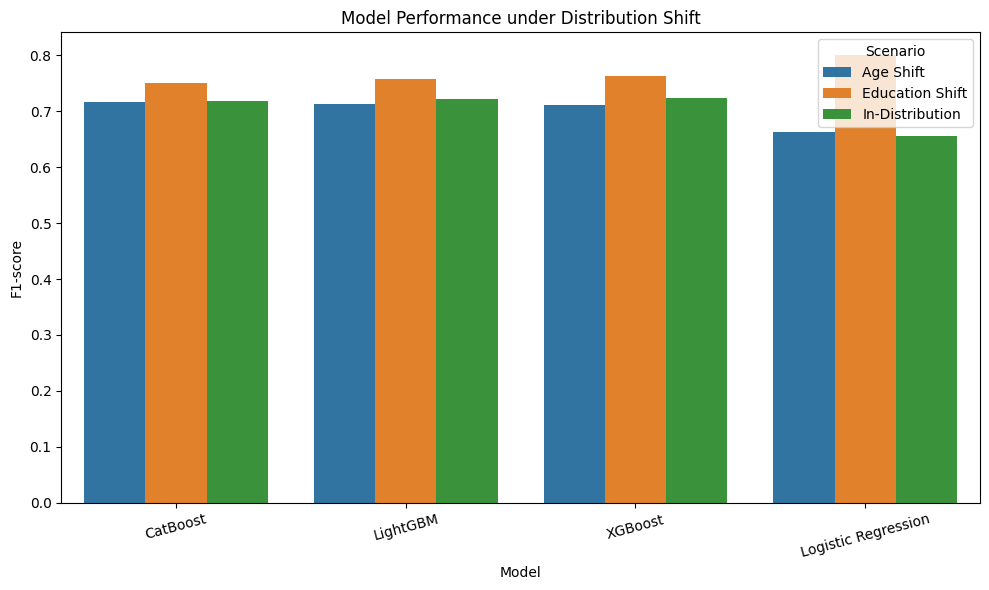

In [27]:
#Plot F1-score by scenario
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="F1-score", hue="Scenario")
plt.title("Model Performance under Distribution Shift")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

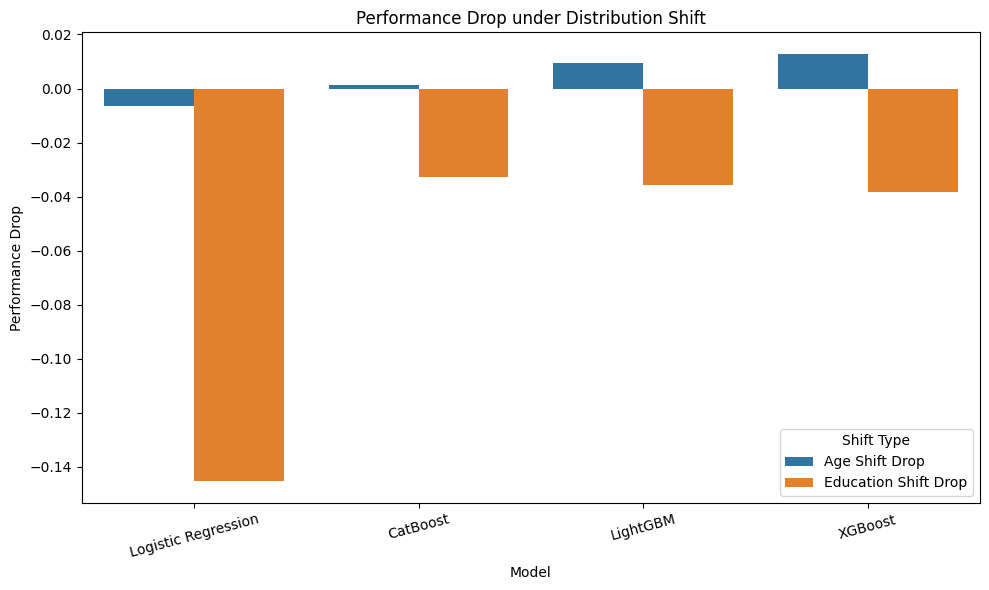

In [28]:
#Plot performance drop
drop_df = pivot_f1[["Age Shift Drop", "Education Shift Drop"]].reset_index()
drop_df = drop_df.melt(id_vars="Model", var_name="Shift Type", value_name="Performance Drop")

plt.figure(figsize=(10, 6))
sns.barplot(data=drop_df, x="Model", y="Performance Drop", hue="Shift Type")
plt.title("Performance Drop under Distribution Shift")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

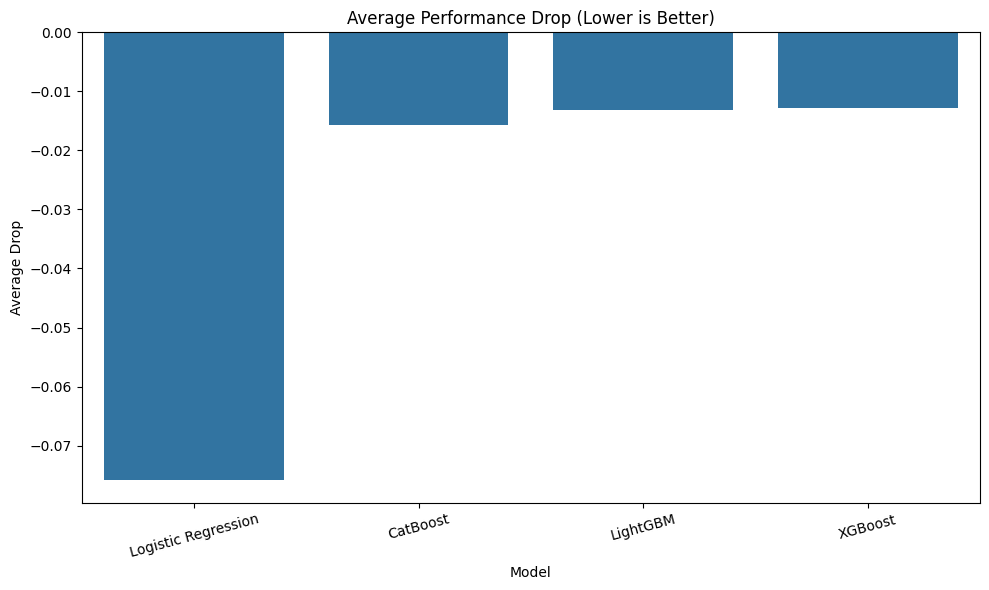

In [29]:
#Stability ranking plot
rank_df = pivot_f1.reset_index().sort_values("Average Drop")

plt.figure(figsize=(10, 6))
sns.barplot(data=rank_df, x="Model", y="Average Drop")
plt.title("Average Performance Drop (Lower is Better)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

H. Detailed classification reports

In [30]:
#Print classification reports
for key, (y_true, y_pred) in saved_predictions.items():
    print("=" * 80)
    print(key)
    print(classification_report(y_true, y_pred, digits=4))

In-Distribution_Logistic Regression
              precision    recall  f1-score   support

           0     0.8794    0.9314    0.9046      7431
           1     0.7314    0.5941    0.6557      2338

    accuracy                         0.8507      9769
   macro avg     0.8054    0.7627    0.7801      9769
weighted avg     0.8440    0.8507    0.8451      9769

In-Distribution_XGBoost
              precision    recall  f1-score   support

           0     0.9007    0.9433    0.9215      7431
           1     0.7880    0.6694    0.7239      2338

    accuracy                         0.8778      9769
   macro avg     0.8443    0.8064    0.8227      9769
weighted avg     0.8737    0.8778    0.8742      9769

In-Distribution_LightGBM
              precision    recall  f1-score   support

           0     0.8991    0.9450    0.9215      7431
           1     0.7912    0.6630    0.7214      2338

    accuracy                         0.8775      9769
   macro avg     0.8452    0.8040    0.8214

I. Save results

In [31]:
#Save main results
results_df.to_csv("/content/model_results_distribution_shift.csv", index=False)
pivot_f1.to_csv("/content/model_stability_ranking.csv")

print("Saved:")
print("/content/model_results_distribution_shift.csv")
print("/content/model_stability_ranking.csv")

Saved:
/content/model_results_distribution_shift.csv
/content/model_stability_ranking.csv


In [32]:
#Download files
from google.colab import files

files.download("/content/model_results_distribution_shift.csv")
files.download("/content/model_stability_ranking.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

J. Optional: save figures

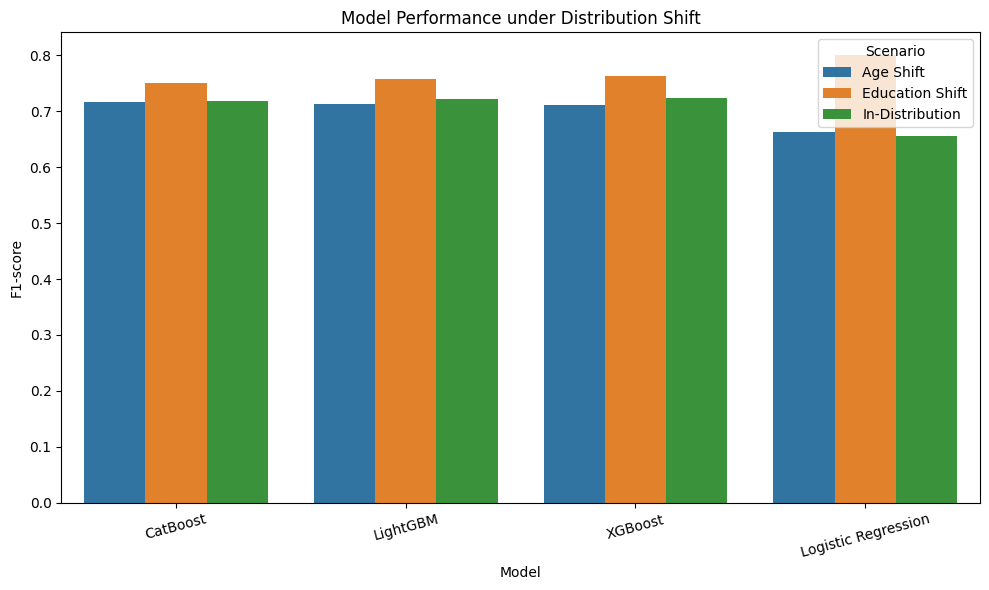

In [33]:
#Save F1-score figure
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="F1-score", hue="Scenario")
plt.title("Model Performance under Distribution Shift")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("/content/f1_score_distribution_shift.png", dpi=300, bbox_inches="tight")
plt.show()

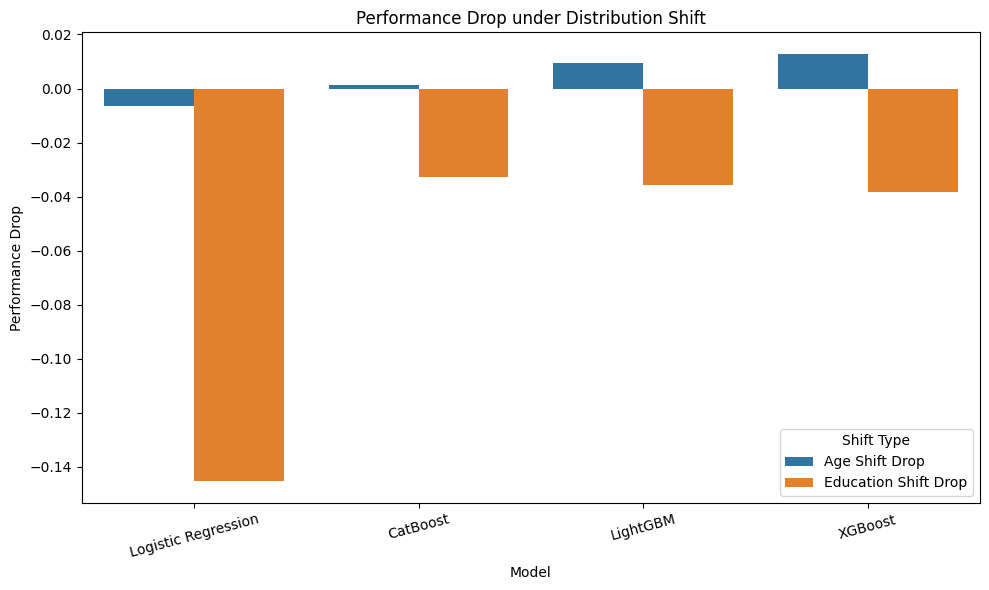

In [34]:
#Save performance drop figu
drop_df = pivot_f1[["Age Shift Drop", "Education Shift Drop"]].reset_index()
drop_df = drop_df.melt(id_vars="Model", var_name="Shift Type", value_name="Performance Drop")

plt.figure(figsize=(10, 6))
sns.barplot(data=drop_df, x="Model", y="Performance Drop", hue="Shift Type")
plt.title("Performance Drop under Distribution Shift")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("/content/performance_drop_distribution_shift.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
#Download Figures
files.download("/content/f1_score_distribution_shift.png")
files.download("/content/performance_drop_distribution_shift.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>